# 쿨링 샴푸 리뷰 분석

상품 데이터 분석에서는 `쿨링 샴푸` 검색 결과가 브랜드, 가격대, 상품명 소구 포인트 측면에서 어떻게 구성되어 있는지 확인했습니다.  
그 결과 브랜드는 분산형 경쟁 구조에 가까웠고, 가격은 1만원대 중심, 상품명은 `쿨링`, `두피 케어`, `유분 관리` 메시지를 반복적으로 강조하고 있었습니다.

하지만 상품 정보만으로는 소비자가 실제로 무엇에 만족했는지, 어떤 점을 불편하게 느꼈는지까지 파악하기 어렵습니다.  
따라서 이번 리뷰 분석에서는 실제 소비자 리뷰를 기준으로 상품 메시지와 소비자 경험이 어떻게 연결되는지 확인합니다.

## 현재 노트북의 범위

전체 프로젝트 중 이 노트북은 리뷰 데이터의 구조 확인, 전처리, 정량 반응 분석을 담당합니다.  
리뷰 본문을 직접 분석하는 텍스트 분석은 다음 노트북인 `04_review_text_analysis.ipynb`에서 진행합니다.

- **3-2. 리뷰 데이터 구조 확인**
- **4-2. 리뷰 데이터 전처리**
- **5-2. 리뷰 EDA**
  - 리뷰 평점 분포
  - 브랜드별 리뷰 반응
  - 가격대별 리뷰 반응
  - 도움돼요구간별 리뷰 특성
  - 리뷰 길이와 평점의 관계
  - 옵션혜택별 리뷰 반응


## 데이터 설명

이번 분석에는 올리브영 온라인몰에서 `쿨링 샴푸` 키워드로 검색한 상품들의 리뷰 데이터를 사용합니다.  
리뷰는 `리뷰 많은 순`으로 정렬된 상품 목록에서 수집한 상품별 리뷰를 기준으로 구성했습니다.

- **출처**: [올리브영 온라인몰 `쿨링 샴푸` 검색 결과](https://www.oliveyoung.co.kr/store/search/getSearchMain.do?query=%EC%BF%A8%EB%A7%81%20%EC%83%B4%ED%91%B8)
- **정렬 기준**: 리뷰 많은 순
- **분석 단위**: 리뷰 1개 = 1행
- **주요 컬럼**: `브랜드`, `상품명`, `가격`, `옵션명`, `리뷰내용`, `리뷰평점`, `도움돼요수`, `사진여부`

### 컬럼 메모

주요 분석 컬럼은 **굵게** 표시했습니다.

- `리뷰순위`: 상품 목록에서의 수집 순위
- **`브랜드`**: 리뷰가 작성된 상품의 브랜드명
- **`상품명`**: 리뷰가 작성된 상품명
- **`가격`**: 리뷰가 작성된 상품의 가격
- `상품내리뷰번호`: 상품별 리뷰 수집 순서
- `리뷰ID`: 리뷰 식별 ID
- **`리뷰내용`**: 소비자가 작성한 리뷰 텍스트
- **`리뷰평점`**: 소비자가 부여한 리뷰 평점
- **`도움돼요수`**: 해당 리뷰가 받은 도움돼요 수
- **`사진여부`**: 리뷰에 사진이 포함되어 있는지 여부
- **`옵션명`**: 리뷰가 작성된 상품 옵션명


## 1. 라이브러리 불러오기

리뷰 데이터 처리와 시각화에 필요한 기본 라이브러리를 불러옵니다.  
텍스트 분석을 위해 정규표현식과 단어 빈도 계산 도구도 함께 사용합니다.

In [1]:
# 데이터 처리
import pandas as pd
import numpy as np

# 텍스트 처리
import re
from collections import Counter

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정
import matplotlib.font_manager as fm

In [2]:
# 출력 옵션 설정
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.1f}".format)

In [3]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 2. 데이터 불러오기

크롤링 단계에서 저장한 리뷰 데이터를 불러옵니다.  
이후 분석에서는 `reviews` 데이터를 기준으로 리뷰 구조와 소비자 반응을 살펴봅니다.

In [4]:
# 리뷰 데이터 불러오기
reviews = pd.read_csv("data/oliveyoung_cooling_shampoo_reviews.csv")

reviews.head()

,리뷰순위,브랜드,상품명,가격,상품내리뷰번호,리뷰ID,리뷰내용,리뷰평점,도움돼요수,사진여부,옵션명
0,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",1,62073431,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,5,"7,614.0",False,쿨링 510ml
1,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",2,61062952,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",5,"5,310.0",True,쿨링 510ml
2,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",3,61757094,🏷️사용감\r\n분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다\r\n\r\n🏷️장점\r\n-분...,5,"4,500.0",True,레몬 1입
3,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",4,61825678,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,5,"4,356.0",True,쿨링 510ml
4,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",5,61971835,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,5,"3,294.0",False,레몬 510ml


In [5]:
# 데이터 크기 확인
print(f"리뷰 {reviews.shape[0]}개, 컬럼 {reviews.shape[1]}개")

리뷰 753개, 컬럼 11개


## 3. 리뷰 데이터 구조 확인

리뷰 분석에 앞서 데이터의 기본 구조를 확인합니다.  
리뷰 수, 컬럼 구성, 결측치, 평점 범위, 리뷰 텍스트 형태를 먼저 살펴봅니다.

### 3-2. 리뷰 데이터 구조 확인

리뷰 데이터가 어떤 컬럼으로 구성되어 있는지 확인합니다.  
특히 이후 분석에 사용할 `리뷰 내용`, `평점`, `도움돼요 수` 관련 컬럼을 중심으로 살펴봅니다.

In [6]:
# 컬럼 확인
reviews.columns

Index(['리뷰순위', '브랜드', '상품명', '가격', '상품내리뷰번호', '리뷰ID', '리뷰내용', '리뷰평점', '도움돼요수',
       '사진여부', '옵션명'],
      dtype='object')

In [7]:
# 데이터 타입 및 결측치 개요 확인
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   리뷰순위     753 non-null    int64  
 1   브랜드      753 non-null    object 
 2   상품명      753 non-null    object 
 3   가격       753 non-null    object 
 4   상품내리뷰번호  753 non-null    int64  
 5   리뷰ID     753 non-null    int64  
 6   리뷰내용     753 non-null    object 
 7   리뷰평점     753 non-null    int64  
 8   도움돼요수    753 non-null    float64
 9   사진여부     753 non-null    bool   
 10  옵션명      753 non-null    object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 59.7+ KB


In [8]:
# 컬럼별 결측치 확인
reviews.isna().sum()

리뷰순위       0
브랜드        0
상품명        0
가격         0
상품내리뷰번호    0
리뷰ID       0
리뷰내용       0
리뷰평점       0
도움돼요수      0
사진여부       0
옵션명        0
dtype: int64

In [9]:
# 전체 컬럼의 기초 통계 확인
# 숫자형 컬럼은 평균, 최솟값, 최댓값 등을 확인하고 문자형 컬럼은 고유값 수와 최빈값을 확인합니다.
reviews.describe(include="all")

,리뷰순위,브랜드,상품명,가격,상품내리뷰번호,리뷰ID,리뷰내용,리뷰평점,도움돼요수,사진여부,옵션명
count,753.0,753,753,753,753.0,753.0,753,753.0,753.0,753,753
unique,NaN,26,40,37,NaN,NaN,644,NaN,NaN,2,48
top,NaN,달리프,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"8,900원~",NaN,NaN,"달리프 지성샴푸, 베러루트 쿨링샴푸는 답답하고 찝찝한 두피에 쿨링감을 주는데요! 너무 시원해서 할말을 잃을 정도로\r\n개운한 사용감이 인상깊은 샴푸였어요🧊\r\n\r\n여름철 두피 기름기로 고민이 많은 1인...",NaN,NaN,True,
freq,NaN,100,20,40,NaN,NaN,4,NaN,NaN,470,301
mean,19.6,NaN,NaN,NaN,10.3,"48,554,808.9",NaN,4.8,418.9,NaN,NaN
std,11.3,NaN,NaN,NaN,5.7,"17,333,801.8",NaN,0.6,858.0,NaN,NaN
min,1.0,NaN,NaN,NaN,1.0,"6,308,283.0",NaN,1.0,0.1,NaN,NaN
25%,10.0,NaN,NaN,NaN,5.0,"33,553,122.0",NaN,5.0,13.5,NaN,NaN
50%,19.0,NaN,NaN,NaN,10.0,"60,280,290.0",NaN,5.0,36.0,NaN,NaN
75%,29.0,NaN,NaN,NaN,15.0,"61,768,163.0",NaN,5.0,378.0,NaN,NaN


In [10]:
# 도움돼요 수 분포 확인
help_count_raw = pd.to_numeric(reviews["도움돼요수"], errors="coerce")

help_count_quantiles = (
    help_count_raw
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 1])
    .reset_index()
)

help_count_quantiles.columns = ["분위수", "도움돼요수"]
help_count_quantiles["도움돼요수"] = help_count_quantiles["도움돼요수"].round(2)

help_count_quantiles


,분위수,도움돼요수
0,0.0,0.1
1,0.2,13.5
2,0.5,36.0
3,0.8,378.0
4,0.9,"1,504.8"
5,1.0,"7,614.0"


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


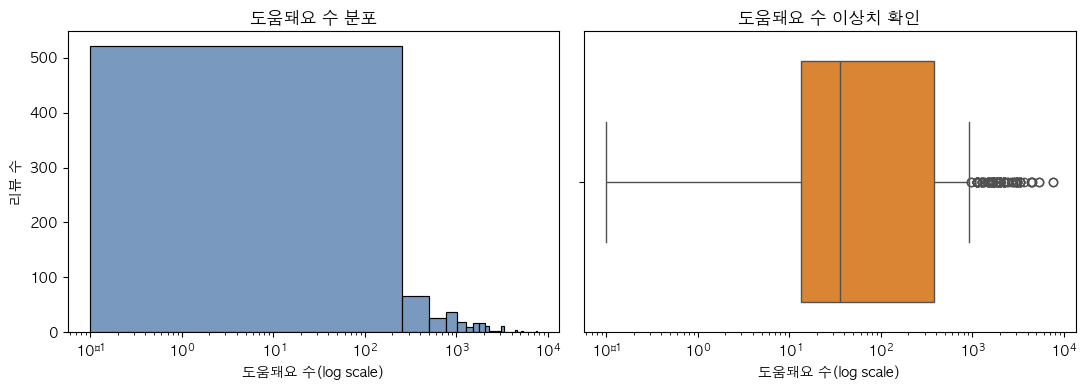

In [11]:
# 도움돼요 수 분포 시각화
# 대부분의 리뷰는 낮은 도움돼요 수에 몰려 있고, 일부 리뷰만 매우 높은 값을 보여 오른쪽으로 긴 꼬리가 확인됩니다.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(help_count_raw, bins=30, ax=axes[0], color="#4C78A8")
axes[0].set_xscale("log")
axes[0].set_title("도움돼요 수 분포")
axes[0].set_xlabel("도움돼요 수(log scale)")
axes[0].set_ylabel("리뷰 수")

sns.boxplot(x=help_count_raw, ax=axes[1], color="#F58518")
axes[1].set_xscale("log")
axes[1].set_title("도움돼요 수 이상치 확인")
axes[1].set_xlabel("도움돼요 수(log scale)")

plt.tight_layout()
plt.show()


In [12]:
# 중복 리뷰 수 확인
# 같은 리뷰 ID와 내용이 반복되는지, 같은 리뷰 내용이 여러 번 등장하는지 함께 확인합니다.
review_text_for_duplicate = (
    reviews["리뷰내용"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

empty_review_count_raw = (review_text_for_duplicate == "").sum()
duplicate_review_count = reviews.duplicated(["리뷰ID", "리뷰내용"]).sum()
duplicate_review_text_count = review_text_for_duplicate.duplicated().sum()

pd.DataFrame({
    "항목": ["빈 리뷰 수", "중복 리뷰 수(ID+내용 기준)", "중복 리뷰 내용 수"],
    "값": [empty_review_count_raw, duplicate_review_count, duplicate_review_text_count],
})


,항목,값
0,빈 리뷰 수,0
1,중복 리뷰 수(ID+내용 기준),95
2,중복 리뷰 내용 수,109


In [13]:
# 중복 리뷰 내용 샘플 확인
# 같은 리뷰 내용이 여러 번 등장한 경우, 어떤 상품/옵션에서 반복되는지 확인합니다.
duplicate_review_samples = reviews.assign(리뷰내용_정리=review_text_for_duplicate)

duplicate_review_samples = (
    duplicate_review_samples[duplicate_review_samples["리뷰내용_정리"].duplicated(keep=False)]
    .assign(중복횟수=lambda df: df.groupby("리뷰내용_정리")["리뷰내용_정리"].transform("count"))
    .sort_values(["중복횟수", "리뷰내용_정리"], ascending=[False, True])
)

duplicate_review_samples[["중복횟수", "브랜드", "상품명", "옵션명", "리뷰평점", "리뷰내용_정리"]].head(10)


,중복횟수,브랜드,상품명,옵션명,리뷰평점,리뷰내용_정리
195,4,달리프,[쿨링감UP/탈모증상완화] 달리프 애플민트 쿨링 샴푸 500ml,500ml1+1기획,5,"달리프 지성샴푸, 베러루트 쿨링샴푸는 답답하고 찝찝한 두피에 쿨링감을 주는데요! 너무 시원해서 할말을 잃을 정도로 개운한 사용감이 인상깊은 샴푸였어요🧊 여름철 두피 기름기로 고민이 많은 1인으로서 이 샴푸를 ..."
198,4,달리프,[쿨링감UP/탈모증상완화] 달리프 애플민트 쿨링 샴푸 500ml,500ml1+1기획,5,"달리프 지성샴푸, 베러루트 쿨링샴푸는 답답하고 찝찝한 두피에 쿨링감을 주는데요! 너무 시원해서 할말을 잃을 정도로 개운한 사용감이 인상깊은 샴푸였어요🧊 여름철 두피 기름기로 고민이 많은 1인으로서 이 샴푸를 ..."
215,4,달리프,[쿨링감UP/탈모완화]달리프 애플민트 쿨링 샴푸 더블기획 (500ml+500ml),500ml1+1기획,5,"달리프 지성샴푸, 베러루트 쿨링샴푸는 답답하고 찝찝한 두피에 쿨링감을 주는데요! 너무 시원해서 할말을 잃을 정도로 개운한 사용감이 인상깊은 샴푸였어요🧊 여름철 두피 기름기로 고민이 많은 1인으로서 이 샴푸를 ..."
218,4,달리프,[쿨링감UP/탈모완화]달리프 애플민트 쿨링 샴푸 더블기획 (500ml+500ml),500ml1+1기획,5,"달리프 지성샴푸, 베러루트 쿨링샴푸는 답답하고 찝찝한 두피에 쿨링감을 주는데요! 너무 시원해서 할말을 잃을 정도로 개운한 사용감이 인상깊은 샴푸였어요🧊 여름철 두피 기름기로 고민이 많은 1인으로서 이 샴푸를 ..."
403,4,아베다,아베다 로즈메리 민트 퓨리파잉 샴푸 250ml,,5,샴푸는 좋은 제품을 한번 사용하고 나면 대기업에서 대량으로 생산되는 저렴이 제품으로 다시 돌아가기 힘든데 아베다 샴푸를 접한 이후로는 마트용 샴푸는 눈길조차 주지 않고 아베다 제품을 전전하고 있는 1인입니다....
520,4,아베다,아베다 로즈메리 민트 퓨리파잉 샴푸 1000ml,,5,샴푸는 좋은 제품을 한번 사용하고 나면 대기업에서 대량으로 생산되는 저렴이 제품으로 다시 돌아가기 힘든데 아베다 샴푸를 접한 이후로는 마트용 샴푸는 눈길조차 주지 않고 아베다 제품을 전전하고 있는 1인입니다....
531,4,아베다,아베다 로즈메리 민트 퓨리파잉 샴푸 1000ml,,5,샴푸는 좋은 제품을 한번 사용하고 나면 대기업에서 대량으로 생산되는 저렴이 제품으로 다시 돌아가기 힘든데 아베다 샴푸를 접한 이후로는 마트용 샴푸는 눈길조차 주지 않고 아베다 제품을 전전하고 있는 1인입니다....
532,4,아베다,아베다 로즈메리 민트 퓨리파잉 샴푸 1000ml,,5,샴푸는 좋은 제품을 한번 사용하고 나면 대기업에서 대량으로 생산되는 저렴이 제품으로 다시 돌아가기 힘든데 아베다 샴푸를 접한 이후로는 마트용 샴푸는 눈길조차 주지 않고 아베다 제품을 전전하고 있는 1인입니다....
313,4,달리프,달리프 쿨링 드라이 샴푸 200ml*2개,쿨링 드라이샴푸,5,"🫶전 올영 메이트의 찐 간증 후기🫶 솔직히 맨날 머리 감고 나가기 귀찮을 때가 있잖아요,,,? 활동을 얼마 안하고 들어올 거라던지,,, 아님 여름에는 아침에 머리를 감아도 지성 두피다 보니까 금방 떡이져서 스..."
316,4,달리프,달리프 쿨링 드라이 샴푸 200ml*2개,쿨링 드라이샴푸,5,"🫶전 올영 메이트의 찐 간증 후기🫶 솔직히 맨날 머리 감고 나가기 귀찮을 때가 있잖아요,,,? 활동을 얼마 안하고 들어올 거라던지,,, 아님 여름에는 아침에 머리를 감아도 지성 두피다 보니까 금방 떡이져서 스..."


In [14]:
# 리뷰 텍스트 예시 확인
# 텍스트 분석에 사용할 리뷰 컬럼의 형태를 먼저 살펴봅니다.
reviews.head(3)

,리뷰순위,브랜드,상품명,가격,상품내리뷰번호,리뷰ID,리뷰내용,리뷰평점,도움돼요수,사진여부,옵션명
0,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",1,62073431,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,5,"7,614.0",False,쿨링 510ml
1,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",2,61062952,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",5,"5,310.0",True,쿨링 510ml
2,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",3,61757094,🏷️사용감\r\n분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다\r\n\r\n🏷️장점\r\n-분...,5,"4,500.0",True,레몬 1입


### 구조 확인 요약

- 리뷰 데이터는 총 **753개 행, 11개 컬럼**으로 구성되어 있습니다.
- 리뷰 내용, 평점, 도움돼요 수, 사진 여부 등 리뷰 반응을 확인할 수 있는 컬럼이 포함되어 있습니다.
- 빈 리뷰는 발견되지 않았으며, 같은 리뷰 내용이 반복된 행이 일부 확인되었습니다. → 중복 리뷰는 특정 문장이 분석 결과에 과하게 반영될 수 있어, 이후 전처리 단계에서 1개만 남기고 제거 예정
- 리뷰 평점은 5점에 많이 몰려 있어, 평점만으로는 소비자 반응의 차이를 자세히 보기 어렵습니다.
- `도움돼요수`는 소수 형태로 저장되어 있어, 실제 클릭 수로 해석하기보다 리뷰 간 상대적인 관심도 지표로 활용합니다. → 이후 전처리 단계에서는 분포를 기준으로 `낮음`, `보통`, `높음`, `매우 높음` 구간으로 나누어 분석 예정
- `리뷰ID`는 리뷰를 구분하기 위한 식별값으로만 사용하며, 작성자 정보로 해석하지 않습니다.

## 4. 리뷰 데이터 전처리

원본 리뷰 데이터를 분석에 사용하기 좋은 형태로 정리합니다.  
이번 단계에서는 리뷰 텍스트를 정리하고, 리뷰 길이와 같은 파생 변수를 생성합니다.


### 4-2. 리뷰 데이터 전처리

리뷰 EDA와 텍스트 분석에 필요한 컬럼을 중심으로 데이터를 정리합니다.  
리뷰 내용, 평점, 도움돼요 구간, 가격대, 옵션명을 확인하고 이후 분석에 사용할 `review_data`를 생성합니다.

**전처리에서 할 일**
- 분석 컬럼 선택
- 리뷰 텍스트 공백 정리
- 옵션명 텍스트 정리
- 옵션 혜택/구성 신호 추출
- 빈 리뷰 및 중복 리뷰 확인
- 중복 리뷰 내용 제거
- 평점/도움돼요 수치형 확인
- 도움돼요 수 구간화
- 가격 숫자형 변환 및 가격대 생성
- 리뷰 길이 변수 생성
- 최종 분석 데이터 구조 확인


In [15]:
# 원본 데이터 보존을 위해 복사본 생성
review_data = reviews.copy()

review_data.head()


,리뷰순위,브랜드,상품명,가격,상품내리뷰번호,리뷰ID,리뷰내용,리뷰평점,도움돼요수,사진여부,옵션명
0,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",1,62073431,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,5,"7,614.0",False,쿨링 510ml
1,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",2,61062952,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",5,"5,310.0",True,쿨링 510ml
2,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",3,61757094,🏷️사용감\r\n분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다\r\n\r\n🏷️장점\r\n-분...,5,"4,500.0",True,레몬 1입
3,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",4,61825678,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,5,"4,356.0",True,쿨링 510ml
4,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",5,61971835,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,5,"3,294.0",False,레몬 510ml


In [16]:
# 분석에 사용할 컬럼 선택
# 리뷰순위와 상품내리뷰번호는 수집 순서에 가까워 분석 컬럼에서는 제외합니다.
review_cols = ["브랜드", "상품명", "가격", "리뷰ID", "리뷰내용", "리뷰평점", "도움돼요수", "사진여부", "옵션명"]

review_data = review_data[review_cols].copy()

review_data.head()


,브랜드,상품명,가격,리뷰ID,리뷰내용,리뷰평점,도움돼요수,사진여부,옵션명
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",62073431,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,5,"7,614.0",False,쿨링 510ml
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",61062952,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",5,"5,310.0",True,쿨링 510ml
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",61757094,🏷️사용감\r\n분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다\r\n\r\n🏷️장점\r\n-분...,5,"4,500.0",True,레몬 1입
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",61825678,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,5,"4,356.0",True,쿨링 510ml
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",61971835,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,5,"3,294.0",False,레몬 510ml


In [17]:
# 리뷰 텍스트 공백 정리
# 줄바꿈과 연속 공백을 하나의 공백으로 정리합니다.
review_data["리뷰내용"] = (review_data["리뷰내용"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip())

review_data[["브랜드", "상품명", "리뷰내용"]].head()


,브랜드,상품명,리뷰내용
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생..."
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!


In [18]:
# 옵션명 텍스트 정리
# 옵션명에서 혜택/구성 신호를 따로 뽑고, 옵션명 자체는 향/쿨링 타입 중심으로 정리합니다.
option_raw = review_data["옵션명"].fillna("").astype(str)

benefit_keywords = {
    "1+1": r"1\s*\+\s*1",
    "기획": r"기획",
    "증정": r"증정",
    "단품": r"단품",
    "올영픽": r"올영픽",
    "신상": r"NEW|New|new",
}

def extract_option_benefit(text):
    matched = [label for label, pattern in benefit_keywords.items() if re.search(pattern, text)]
    return ", ".join(matched) if matched else "일반"

review_data["옵션혜택"] = option_raw.apply(extract_option_benefit)

review_data["옵션명"] = (
    option_raw
    .str.replace(r"(?i)\d+(?:\.\d+)?\s*ml", " ", regex=True)
    .str.replace(r"\d+\s*\+\s*\d+", " ", regex=True)
    .str.replace(r"\d+\s*입", " ", regex=True)
    .str.replace(r"\bS\d+\b", " ", regex=True)
    .str.replace(r"NEW|New|new|기획|증정|단품|올영픽", " ", regex=True)
    .str.replace(r"\d+", " ", regex=True)
    .str.replace(r"[\[\]\(\)\+/,]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

review_data["옵션명"] = review_data["옵션명"].replace("", "옵션 없음")

review_data[["상품명", "옵션명", "옵션혜택"]].head(10)


,상품명,옵션명,옵션혜택
0,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),쿨링,일반
1,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),쿨링,일반
2,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),레몬,일반
3,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),쿨링,일반
4,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),레몬,일반
5,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),자몽향,일반
6,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),비누향,일반
7,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),OY단독 복숭아,일반
8,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),복숭아향,일반
9,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),비누향,일반


In [19]:
# 빈 리뷰 및 중복 리뷰 확인
# 구조 확인에서 본 항목을 전처리용 데이터에서도 다시 확인합니다.
review_count_before_dedup = len(review_data)
empty_review_count = (review_data["리뷰내용"] == "").sum()
duplicate_review_count = review_data.duplicated(["리뷰ID", "리뷰내용"]).sum()
duplicate_review_text_count = review_data["리뷰내용"].duplicated().sum()

print("중복 제거 전 리뷰 수:", review_count_before_dedup)
print("빈 리뷰 수:", empty_review_count)
print("중복 리뷰 수(ID+내용 기준):", duplicate_review_count)
print("중복 리뷰 내용 수:", duplicate_review_text_count)


중복 제거 전 리뷰 수: 753
빈 리뷰 수: 0
중복 리뷰 수(ID+내용 기준): 95
중복 리뷰 내용 수: 109


In [20]:
# 중복 리뷰 내용 제거
# 같은 리뷰 내용이 여러 번 반복되면 텍스트 분석과 리뷰 반응 집계가 특정 문장에 치우칠 수 있어 1개만 남깁니다.
review_data = review_data.drop_duplicates("리뷰내용", keep="first").copy()
duplicate_review_removed_count = review_count_before_dedup - len(review_data)

print("중복 제거 후 리뷰 수:", len(review_data))
print("제거된 중복 리뷰 수:", duplicate_review_removed_count)


중복 제거 후 리뷰 수: 644
제거된 중복 리뷰 수: 109


In [21]:
# 평점과 도움돼요 수치형 확인
review_data["리뷰평점"] = pd.to_numeric(review_data["리뷰평점"], errors="coerce")
review_data["도움돼요수"] = pd.to_numeric(review_data["도움돼요수"], errors="coerce")

rating_missing_count = review_data["리뷰평점"].isna().sum()
help_count_missing_count = review_data["도움돼요수"].isna().sum()
review_data["도움돼요수"] = review_data["도움돼요수"].fillna(0)

print("리뷰평점 결측 수:", rating_missing_count)
print("도움돼요수 결측 수:", help_count_missing_count)
print("리뷰평점 범위:", review_data["리뷰평점"].min(), "~", review_data["리뷰평점"].max())
print("도움돼요수 범위:", review_data["도움돼요수"].min(), "~", review_data["도움돼요수"].max())


리뷰평점 결측 수: 0
도움돼요수 결측 수: 0
리뷰평점 범위: 1 ~ 5
도움돼요수 범위: 0.1 ~ 7614.0


In [22]:
# 도움돼요 수 구간화
# 중복 제거 후 데이터의 분위수(Q1, 중앙값, Q3)를 기준으로 도움돼요 수를 구간형 변수로 변환합니다.
help_q1 = review_data["도움돼요수"].quantile(0.25)
help_q2 = review_data["도움돼요수"].quantile(0.50)
help_q3 = review_data["도움돼요수"].quantile(0.75)

help_bins = [-np.inf, help_q1, help_q2, help_q3, np.inf]
help_labels = ["낮음", "보통", "높음", "매우 높음"]

review_data["도움돼요구간"] = pd.cut(
    review_data["도움돼요수"],
    bins=help_bins,
    labels=help_labels,
    include_lowest=True,
)

help_group_summary = review_data["도움돼요구간"].value_counts().reindex(help_labels)

help_group_range = pd.DataFrame({
    "도움돼요구간": help_labels,
    "범위": [
        f"{help_q1:.1f} 이하",
        f"{help_q1:.1f} 초과 ~ {help_q2:.1f} 이하",
        f"{help_q2:.1f} 초과 ~ {help_q3:.1f} 이하",
        f"{help_q3:.1f} 초과",
    ],
    "리뷰 수": help_group_summary.values,
})

help_group_range


,도움돼요구간,범위,리뷰 수
0,낮음,13.5 이하,168
1,보통,13.5 초과 ~ 36.0 이하,160
2,높음,36.0 초과 ~ 360.0 이하,157
3,매우 높음,360.0 초과,159


In [23]:
# 가격 컬럼 숫자형 변환 및 가격대 생성
# 리뷰 반응을 가격대별로도 확인하기 위해 상품 가격을 숫자형으로 정리합니다.
review_data["가격_원본"] = review_data["가격"]

review_data["가격"] = (
    review_data["가격_원본"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("원~", "", regex=False)
    .str.replace("원", "", regex=False)
    .str.replace("~", "", regex=False)
    .str.strip()
)

review_data["가격"] = pd.to_numeric(review_data["가격"], errors="coerce")

bins = [0, 10000, 20000, 30000, np.inf]
labels = ["1만원 미만", "1만원대", "2만원대", "3만원 이상"]

review_data["가격대"] = pd.cut(
    review_data["가격"],
    bins=bins,
    labels=labels,
    right=False,
)

print("가격 변환 실패 수:", review_data["가격"].isna().sum())
review_data[["가격_원본", "가격", "가격대"]].head()


가격 변환 실패 수: 0


,가격_원본,가격,가격대
0,"5,950원~",5950,1만원 미만
1,"5,950원~",5950,1만원 미만
2,"5,950원~",5950,1만원 미만
3,"5,950원~",5950,1만원 미만
4,"5,950원~",5950,1만원 미만


In [24]:
# 리뷰 길이 변수 생성
# 글자 수와 단어 수를 함께 확인해 리뷰 작성량을 비교합니다.
review_data["리뷰글자수"] = review_data["리뷰내용"].str.len()
review_data["리뷰단어수"] = review_data["리뷰내용"].str.split().str.len()

review_data[["리뷰내용", "리뷰글자수", "리뷰단어수"]].head()


,리뷰내용,리뷰글자수,리뷰단어수
0,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,35,8
1,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",246,57
2,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...,288,71
3,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,41,8
4,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,79,18


In [25]:
# 사진 여부 값 확인
review_data["사진여부"].value_counts(dropna=False)


사진여부
True     400
False    244
Name: count, dtype: int64

In [26]:
# 최종 분석용 컬럼 정리
# 구간화와 중복 확인이 끝났으므로 원본 도움돼요수, 원본 가격 문자열, 리뷰ID는 제외합니다.
review_analysis_cols = ["브랜드", "상품명", "가격", "가격대", "옵션명", "옵션혜택", "리뷰내용", "리뷰평점", "도움돼요구간", "사진여부", "리뷰글자수", "리뷰단어수"]

review_data = review_data[review_analysis_cols].copy()

review_data.head()


,브랜드,상품명,가격,가격대,옵션명,옵션혜택,리뷰내용,리뷰평점,도움돼요구간,사진여부,리뷰글자수,리뷰단어수
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,5,매우 높음,False,35,8
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",5,매우 높음,True,246,57
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,레몬,일반,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...,5,매우 높음,True,288,71
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,5,매우 높음,True,41,8
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,레몬,일반,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,5,매우 높음,False,79,18


In [27]:
# 전처리 결과 요약
review_preprocessing_summary = pd.DataFrame({
    "항목": ["중복 제거 전 리뷰 수", "중복 제거 후 리뷰 수", "제거된 중복 리뷰 수", "브랜드 수", "상품 수", "옵션명 수", "옵션혜택 유형 수", "빈 리뷰 수", "중복 리뷰 수(ID+내용 기준)", "중복 리뷰 내용 수", "리뷰내용 결측 수", "리뷰평점 결측 수", "도움돼요수 결측 수", "도움돼요구간 결측 수", "가격 변환 실패 수", "가격대 결측 수", "가격대 구간 수", "평균 리뷰 글자 수", "평균 리뷰 단어 수", "최종 컬럼 수"],
    "값": [review_count_before_dedup, len(review_data), duplicate_review_removed_count, review_data["브랜드"].nunique(), review_data["상품명"].nunique(), review_data["옵션명"].nunique(), review_data["옵션혜택"].nunique(), empty_review_count, duplicate_review_count, duplicate_review_text_count, review_data["리뷰내용"].isna().sum(), rating_missing_count, help_count_missing_count, review_data["도움돼요구간"].isna().sum(), review_data["가격"].isna().sum(), review_data["가격대"].isna().sum(), review_data["가격대"].nunique(), round(review_data["리뷰글자수"].mean(), 1), round(review_data["리뷰단어수"].mean(), 1), review_data.shape[1]],
})

review_preprocessing_summary


,항목,값
0,중복 제거 전 리뷰 수,753.0
1,중복 제거 후 리뷰 수,644.0
2,제거된 중복 리뷰 수,109.0
3,브랜드 수,26.0
4,상품 수,38.0
5,옵션명 수,36.0
6,옵션혜택 유형 수,9.0
7,빈 리뷰 수,0.0
8,중복 리뷰 수(ID+내용 기준),95.0
9,중복 리뷰 내용 수,109.0


### 전처리 결과 확인

전처리가 완료된 리뷰 데이터를 확인합니다.  
이후 리뷰 EDA에서는 `review_data`를 기준으로 평점, 리뷰 길이, 도움돼요 구간 분포와 가격대별 리뷰 반응을 분석합니다.


In [28]:
# 전처리 결과 확인
review_data.head()


,브랜드,상품명,가격,가격대,옵션명,옵션혜택,리뷰내용,리뷰평점,도움돼요구간,사진여부,리뷰글자수,리뷰단어수
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,5,매우 높음,False,35,8
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",5,매우 높음,True,246,57
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,레몬,일반,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...,5,매우 높음,True,288,71
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,5,매우 높음,True,41,8
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,레몬,일반,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,5,매우 높음,False,79,18


### 전처리 요약

**정리 결과**
- 분석에 필요한 리뷰 컬럼만 선별했습니다.
- `리뷰순위`와 `상품내리뷰번호`는 수집 순서에 가까워 최종 분석 컬럼에서는 제외했습니다.
- `옵션명`은 향, 쿨링 타입, 기획 구성 등 상품 메시지를 확인할 수 있어 분석 컬럼으로 유지했습니다.
- `옵션명`에서 용량 단위와 숫자 표현을 제거해 메시지 중심으로 정리했습니다.
- `1+1`, `기획`, `증정`, `단품`, `올영픽`처럼 혜택이나 구성을 나타내는 표현은 `옵션혜택`으로 따로 분리했습니다.
- 리뷰 텍스트의 줄바꿈과 연속 공백을 정리했습니다.
- 같은 리뷰 내용이 반복된 행은 텍스트 분석이 특정 문장에 치우치지 않도록 1개만 남겼습니다.
- `리뷰ID`는 리뷰 자체의 식별값으로 보고, 작성자 ID로 해석하지 않았습니다.
- `리뷰평점`, `도움돼요수`, `가격`을 수치형으로 변환했습니다.
- 중복 제거 후 도움돼요 수 분포를 기준으로 `도움돼요구간`을 생성하고, 원본 `도움돼요수`는 최종 분석 데이터에서 제외했습니다.
- 가격대별 리뷰 반응을 보기 위해 `가격대` 컬럼을 생성했습니다.
- 리뷰 작성량을 비교하기 위해 리뷰 길이 변수를 생성했습니다.

**추가 생성 컬럼**
- `가격`: 숫자형 가격
- `가격대`: 가격 비교를 위한 구간형 변수
- `옵션혜택`: 옵션명에서 추출한 혜택/구성 유형
- `도움돼요구간`: 도움돼요 수 분포 비교를 위한 구간형 변수
- `리뷰글자수`: 리뷰 내용의 전체 글자 수
- `리뷰단어수`: 리뷰 내용의 전체 단어 수

**중복 리뷰 처리 기준**
- 완전히 같은 리뷰 내용이 여러 번 등장한 경우, 첫 번째 리뷰만 남겼습니다.
- 같은 문장이 여러 상품/옵션에 반복되면 키워드 빈도와 클러스터링 결과가 왜곡될 수 있기 때문에 제거했습니다.

**옵션명 정리 기준**
- `ml`, `ML` 등 용량 단위와 숫자 표현은 제거했습니다.
- `쿨링`, `레몬`, `민트`, `라임`, `복숭아`처럼 옵션 메시지를 해석할 수 있는 단어는 `옵션명`에 남겼습니다.
- `1+1`, `기획`, `증정`, `단품`, `올영픽`, `NEW`처럼 구성이나 혜택을 나타내는 표현은 `옵션혜택`으로 분리했습니다.

**도움돼요 수 해석 기준**
- `도움돼요수`는 원본 수집 과정에서 소수 형태로 저장되어 있어, 절대적인 클릭 수로 해석하지 않았습니다.
- 따라서 리뷰 간 상대적 관심도 지표로 보고, 중복 제거 후 분위수 기준으로 `낮음`, `보통`, `높음`, `매우 높음` 구간을 생성했습니다.

**가격대 기준**
- `1만원 미만`: [0, 10,000)
- `1만원대`: [10,000, 20,000)
- `2만원대`: [20,000, 30,000)
- `3만원 이상`: [30,000, ∞)

**이후 분석 활용**
- `리뷰평점`: 리뷰 만족도 분포 확인
- `가격대`: 가격대별 리뷰 반응 비교
- `옵션명`: 향, 쿨링 타입 등 옵션 메시지 확인
- `옵션혜택`: 기획/증정/단품 등 구성 소구 확인
- `도움돼요구간`: 소비자에게 유용하게 받아들여진 리뷰 구간 확인
- `리뷰글자수`, `리뷰단어수`: 리뷰 길이 분포 확인
- `리뷰내용`: 워드클라우드, 키워드 빈도, 긍정/부정 키워드 분석


## 5-2. 리뷰 EDA

전처리한 `review_data`를 기준으로 소비자 반응의 기본 흐름을 확인합니다.  
이 단계에서는 리뷰 본문을 직접 해석하기보다, 평점, 리뷰 길이, 도움돼요 구간, 브랜드, 가격대, 옵션혜택 같은 정량 지표를 중심으로 살펴봅니다.  
이후 텍스트 분석에서 어떤 키워드를 더 집중해서 볼지 정하기 위한 사전 탐색 단계입니다.


#### 5-2-1. 리뷰 평점 분포

리뷰 평점이 전체적으로 어느 점수대에 몰려 있는지 확인합니다.  
평점 분포는 소비자 만족도의 기본 방향을 보여주지만, 구체적인 만족/불만 이유는 이후 텍스트 분석에서 함께 확인해야 합니다.


In [29]:
# 리뷰 평점 분포 집계
rating_counts = (review_data["리뷰평점"].value_counts().sort_index().reset_index())

rating_counts.columns = ["리뷰평점", "리뷰 수"]
rating_counts["비율(%)"] = (rating_counts["리뷰 수"] / len(review_data) * 100).round(1)

rating_counts


,리뷰평점,리뷰 수,비율(%)
0,1,2,0.3
1,2,8,1.2
2,3,21,3.3
3,4,67,10.4
4,5,546,84.8


In [30]:
# 리뷰 평점 요약 지표
high_rating_ratio = (review_data["리뷰평점"] >= 4).mean() * 100
low_rating_ratio = (review_data["리뷰평점"] <= 3).mean() * 100
five_star_ratio = (review_data["리뷰평점"] == 5).mean() * 100

rating_summary = pd.DataFrame({
    "항목": ["전체 리뷰 수", "평균 평점", "중앙값", "5점 리뷰 비율", "4점 이상 리뷰 비율", "3점 이하 리뷰 비율"],
    "값": [len(review_data), round(review_data["리뷰평점"].mean(), 2), review_data["리뷰평점"].median(), f"{five_star_ratio:.1f}%", f"{high_rating_ratio:.1f}%", f"{low_rating_ratio:.1f}%"],
})

rating_summary


,항목,값
0,전체 리뷰 수,644
1,평균 평점,4.8
2,중앙값,5.0
3,5점 리뷰 비율,84.8%
4,4점 이상 리뷰 비율,95.2%
5,3점 이하 리뷰 비율,4.8%


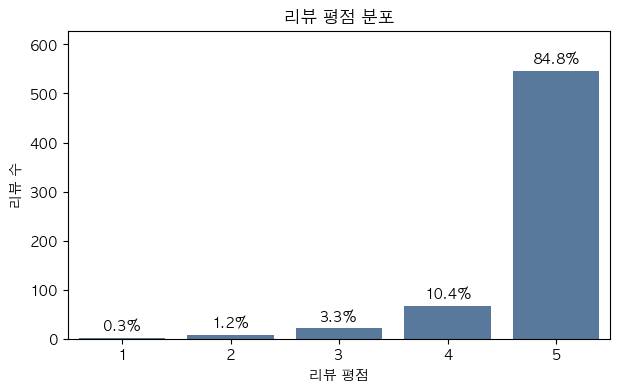

In [31]:
# 리뷰 평점 분포 시각화
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=rating_counts, x="리뷰평점", y="리뷰 수", color="#4C78A8")

for i, row in rating_counts.iterrows():
    ax.text(i, row["리뷰 수"] + 8, f'{row["비율(%)"]}%', ha="center", va="bottom", fontsize=10)

plt.title("리뷰 평점 분포")
plt.xlabel("리뷰 평점")
plt.ylabel("리뷰 수")
plt.ylim(0, rating_counts["리뷰 수"].max() * 1.15)
plt.show()


**리뷰 평점 분포 요약**

- 중복 제거 후 전체 리뷰 <b>644건</b> 중 <b>5점 리뷰가 546건(84.8%)</b>으로 가장 많았습니다.
- 평균 평점은 <b>4.78점</b>이며, 중앙값도 <b>5점</b>으로 전반적인 만족도는 높게 나타났습니다.
- <b>4점 이상 리뷰는 95.2%</b>, <b>3점 이하 리뷰는 4.8%</b>로 낮은 평점 리뷰는 많지 않았습니다.
- 따라서 평점만 보면 상품 만족도가 전반적으로 높아 보이지만, 불편 요소가 평점에 충분히 드러나지 않을 수 있습니다.


#### 5-2-2. 브랜드별 리뷰 반응

브랜드별로 리뷰 수, 평균 평점, 5점 비율, 도움돼요 반응을 함께 확인합니다.  
단순 리뷰 수뿐 아니라 만족도와 관심도까지 같이 보면 브랜드별 반응 차이를 더 입체적으로 볼 수 있습니다.


In [32]:
# 브랜드별 리뷰 반응 집계
brand_review_response = (
    review_data
    .groupby("브랜드")
    .agg(
        리뷰수=("리뷰내용", "count"),
        평균평점=("리뷰평점", "mean"),
        평균리뷰글자수=("리뷰글자수", "mean"),
        매우높은도움돼요비율=("도움돼요구간", lambda x: (x == "매우 높음").mean() * 100),
        오점비율=("리뷰평점", lambda x: (x == 5).mean() * 100),
    )
    .reset_index()
)

brand_review_response["평균평점"] = brand_review_response["평균평점"].round(2)
brand_review_response["평균리뷰글자수"] = brand_review_response["평균리뷰글자수"].round(1)
brand_review_response["매우높은도움돼요비율"] = brand_review_response["매우높은도움돼요비율"].round(1)
brand_review_response["오점비율"] = brand_review_response["오점비율"].round(1)
brand_review_response = brand_review_response.sort_values(["리뷰수", "평균평점"], ascending=[False, False])

brand_review_response.head(10)


,브랜드,리뷰수,평균평점,평균리뷰글자수,매우높은도움돼요비율,오점비율
7,달리프,65,4.7,169.5,6.2,75.4
21,클로란,55,4.7,134.8,14.5,78.2
18,온더바디,41,4.9,109.6,100.0,97.6
2,닥터그루트,40,4.8,144.3,0.0,87.5
10,려,39,4.9,158.8,64.1,94.9
9,라보에이치,39,4.8,114.3,38.5,84.6
17,아베다,35,4.7,326.5,2.9,82.9
6,닥터포헤어,22,4.9,195.6,54.5,86.4
15,아도르,20,5.0,132.4,5.0,100.0
19,원오세븐,20,5.0,161.8,45.0,100.0


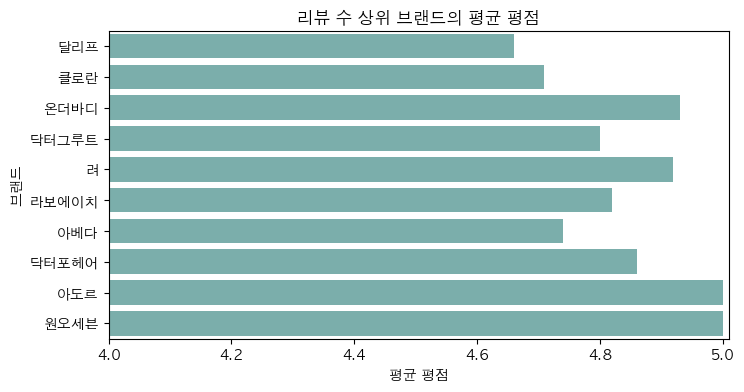

In [33]:
# 리뷰 수 상위 브랜드의 평균 평점 비교
brand_top10 = brand_review_response.head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=brand_top10, x="평균평점", y="브랜드", color="#72B7B2")
plt.title("리뷰 수 상위 브랜드의 평균 평점")
plt.xlabel("평균 평점")
plt.ylabel("브랜드")
plt.xlim(4, 5.01)
plt.show()


**브랜드별 리뷰 반응 요약**

- 중복 제거 후 리뷰 수는 <b>달리프(65건)</b>가 가장 많고, 그다음으로 <b>클로란(55건)</b>, <b>온더바디(41건)</b>가 뒤를 이었습니다.
- 리뷰 수 상위 브랜드의 평균 평점은 대부분 4점대 후반으로 높게 나타났지만, <b>달리프는 4.66점</b>으로 상위 브랜드 중 상대적으로 낮았습니다.
- <b>온더바디</b>는 평균 평점이 <b>4.93점</b>으로 높고, 도움돼요 반응도 높은 구간에 많이 포함되어 주목할 만합니다.
- 따라서 브랜드별 차이는 단순 리뷰 수보다 평점, 도움돼요구간, 리뷰 내용까지 함께 봐야 더 잘 드러납니다.


#### 5-2-3. 가격대별 리뷰 반응

전처리에서 만든 `가격대`를 기준으로 리뷰 수와 평균 평점을 비교합니다.  
가격대별로 리뷰가 어느 구간에 많이 쌓였는지, 높은 가격대에서도 만족도가 유지되는지 확인합니다.


In [34]:
# 가격대별 리뷰 반응 집계
price_review_response = (
    review_data
    .groupby("가격대", observed=False)
    .agg(리뷰수=("리뷰내용", "count"), 평균평점=("리뷰평점", "mean"), 평균리뷰글자수=("리뷰글자수", "mean"))
    .reset_index()
)

price_review_response["리뷰비율(%)"] = (price_review_response["리뷰수"] / len(review_data) * 100).round(1)
price_review_response["평균평점"] = price_review_response["평균평점"].round(2)
price_review_response["평균리뷰글자수"] = price_review_response["평균리뷰글자수"].round(1)

price_review_response


,가격대,리뷰수,평균평점,평균리뷰글자수,리뷰비율(%)
0,1만원 미만,160,4.8,169.9,24.8
1,1만원대,295,4.8,147.6,45.8
2,2만원대,139,4.7,107.0,21.6
3,3만원 이상,50,4.7,302.2,7.8


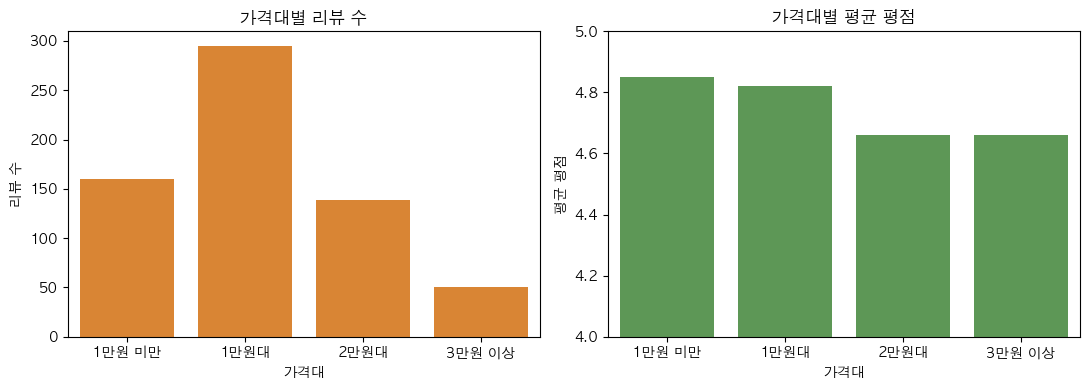

In [35]:
# 가격대별 리뷰 수와 평균 평점 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=price_review_response, x="가격대", y="리뷰수", color="#F58518", ax=axes[0])
axes[0].set_title("가격대별 리뷰 수")
axes[0].set_xlabel("가격대")
axes[0].set_ylabel("리뷰 수")

sns.barplot(data=price_review_response, x="가격대", y="평균평점", color="#54A24B", ax=axes[1])
axes[1].set_title("가격대별 평균 평점")
axes[1].set_xlabel("가격대")
axes[1].set_ylabel("평균 평점")
axes[1].set_ylim(4, 5)

plt.tight_layout()
plt.show()


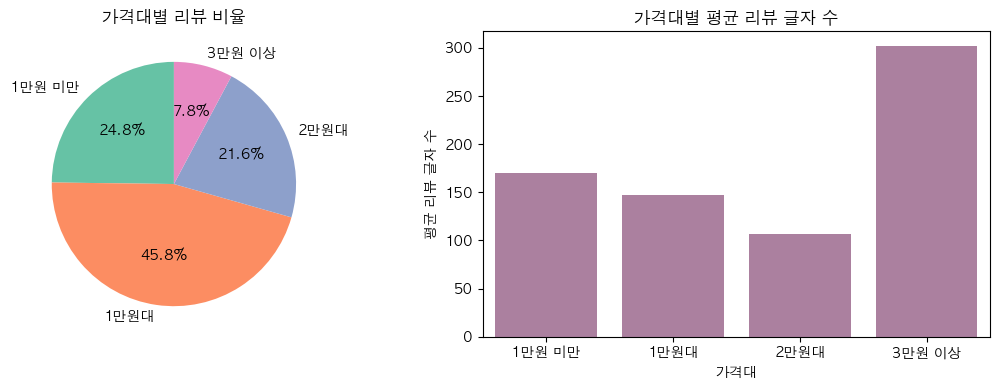

In [36]:
# 가격대별 리뷰 비율과 평균 리뷰 글자 수 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(
    price_review_response["리뷰비율(%)"],
    labels=price_review_response["가격대"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(price_review_response)),
)
axes[0].set_title("가격대별 리뷰 비율")

sns.barplot(data=price_review_response, x="가격대", y="평균리뷰글자수", color="#B279A2", ax=axes[1])
axes[1].set_title("가격대별 평균 리뷰 글자 수")
axes[1].set_xlabel("가격대")
axes[1].set_ylabel("평균 리뷰 글자 수")

plt.tight_layout()
plt.show()


**가격대별 리뷰 반응 요약**

- 리뷰는 <b>1만원대 295건(45.8%)</b>에 가장 많이 분포했고, 그다음은 <b>1만원 미만 160건(24.8%)</b>, <b>2만원대 139건(21.6%)</b>, <b>3만원 이상 50건(7.8%)</b> 순으로 나타났습니다.
- 평균 평점은 <b>1만원 미만(4.85점) > 1만원대(4.82점) > 2만원대 = 3만원 이상(4.66점)</b> 순으로, 저가~중가 구간에서 상대적으로 높게 나타났습니다.
- <b>2만원대</b>와 <b>3만원 이상</b>도 평균 평점은 4점대 후반이지만, 리뷰 수는 상대적으로 적어 반응 규모는 크지 않았습니다.
- 평균 리뷰 글자 수는 <b>3만원 이상(302.2자) > 1만원 미만(169.9자) > 1만원대(147.6자) > 2만원대(107.0자)</b> 순으로 나타났습니다.
- 따라서 쿨링 샴푸 리뷰 반응은 <b>1만원대 중심</b>으로 형성되어 있으며, 고가 구간은 리뷰 수는 적지만 더 긴 리뷰가 작성되는 경향이 확인됩니다.


#### 5-2-4. 도움돼요구간별  리뷰 반응

`도움돼요구간`별로 평점, 리뷰 길이, 사진 여부를 비교합니다.  
또한 도움돼요 반응이 높은 리뷰가 어떤 브랜드, 가격대, 옵션혜택에서 많이 나타나는지 확인합니다.  
이 분석은 이후 텍스트 분석에서 우선적으로 살펴볼 리뷰 그룹을 정하기 위한 기준으로 활용합니다.


In [37]:
# 도움돼요구간별 리뷰 특성 집계
help_review_response = (
    review_data
    .groupby("도움돼요구간", observed=False)
    .agg(리뷰수=("리뷰내용", "count"), 평균평점=("리뷰평점", "mean"), 평균리뷰글자수=("리뷰글자수", "mean"), 사진리뷰비율=("사진여부", lambda x: x.mean() * 100))
    .reset_index()
)

help_review_response["리뷰비율(%)"] = (help_review_response["리뷰수"] / len(review_data) * 100).round(1)
help_review_response["평균평점"] = help_review_response["평균평점"].round(2)
help_review_response["평균리뷰글자수"] = help_review_response["평균리뷰글자수"].round(1)
help_review_response["사진리뷰비율"] = help_review_response["사진리뷰비율"].round(1)

help_review_response


,도움돼요구간,리뷰수,평균평점,평균리뷰글자수,사진리뷰비율,리뷰비율(%)
0,낮음,168,4.7,133.7,49.4,26.1
1,보통,160,4.7,220.0,83.8,24.8
2,높음,157,4.8,128.2,59.2,24.4
3,매우 높음,159,4.9,144.2,56.6,24.7


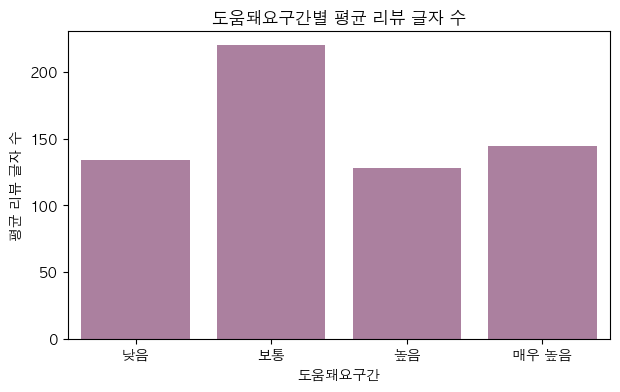

In [38]:
# 도움돼요구간별 리뷰 길이 비교
plt.figure(figsize=(7, 4))
sns.barplot(data=help_review_response, x="도움돼요구간", y="평균리뷰글자수", color="#B279A2")
plt.title("도움돼요구간별 평균 리뷰 글자 수")
plt.xlabel("도움돼요구간")
plt.ylabel("평균 리뷰 글자 수")
plt.show()


In [39]:
# 도움돼요구간별 가격대 분포 확인
help_price_response = pd.crosstab(
    review_data["도움돼요구간"],
    review_data["가격대"],
    normalize="index",
).mul(100).round(1)

help_price_response = help_price_response.reindex(help_labels)
help_price_response


가격대,1만원 미만,1만원대,2만원대,3만원 이상
도움돼요구간,,,,
낮음,4.8,50.0,30.4,14.9
보통,13.1,66.2,6.9,13.8
높음,22.3,46.5,29.9,1.3
매우 높음,60.4,20.1,18.9,0.6


In [40]:
# 매우 높은 도움돼요 반응을 받은 리뷰의 브랜드/옵션혜택 확인
very_high_help_reviews = review_data[review_data["도움돼요구간"] == "매우 높음"].copy()

very_high_help_brand = (
    very_high_help_reviews["브랜드"]
    .value_counts()
    .head(10)
    .reset_index()
)
very_high_help_brand.columns = ["브랜드", "매우 높은 도움돼요 리뷰 수"]

very_high_help_option = (
    very_high_help_reviews["옵션혜택"]
    .value_counts()
    .reset_index()
)
very_high_help_option.columns = ["옵션혜택", "매우 높은 도움돼요 리뷰 수"]

very_high_help_brand


,브랜드,매우 높은 도움돼요 리뷰 수
0,온더바디,41
1,려,25
2,쿤달,20
3,라보에이치,15
4,닥터포헤어,12
5,원오세븐,9
6,마이녹셀,8
7,클로란,8
8,아리얼,7
9,달리프,4


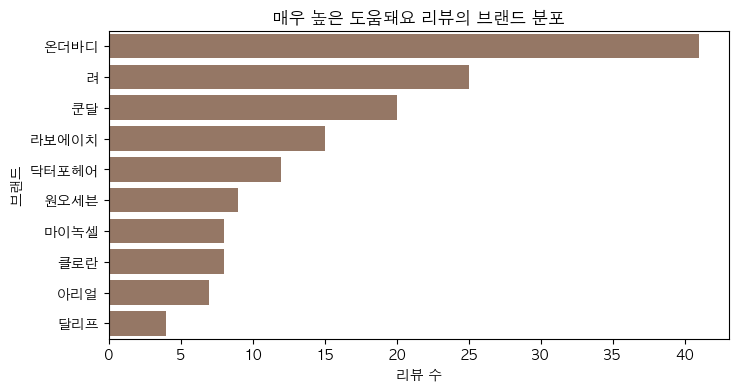

In [41]:
# 매우 높은 도움돼요 리뷰의 브랜드 분포 시각화
plt.figure(figsize=(8, 4))
sns.barplot(data=very_high_help_brand, x="매우 높은 도움돼요 리뷰 수", y="브랜드", color="#9D755D")
plt.title("매우 높은 도움돼요 리뷰의 브랜드 분포")
plt.xlabel("리뷰 수")
plt.ylabel("브랜드")
plt.show()


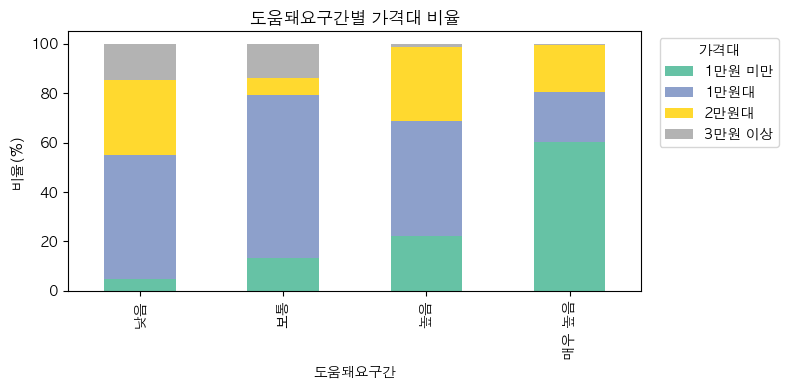

In [42]:
# 도움돼요구간별 가격대 비율 시각화
help_price_response.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2")
plt.title("도움돼요구간별 가격대 비율")
plt.xlabel("도움돼요구간")
plt.ylabel("비율(%)")
plt.legend(title="가격대", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [43]:
# 매우 높은 도움돼요 리뷰의 옵션혜택 분포 확인
very_high_help_option


,옵션혜택,매우 높은 도움돼요 리뷰 수
0,일반,119
1,기획,18
2,단품,9
3,올영픽,5
4,"기획, 증정",4
5,"기획, 신상",2
6,"기획, 증정, 신상",1
7,증정,1


**도움돼요구간별 리뷰 특성 요약**

- `매우 높음` 구간은 평균 평점이 <b>4.91점</b>으로 가장 높아, 긍정 경험이 다른 소비자에게 많이 참고된 것으로 볼 수 있습니다.
- `보통` 구간은 평균 리뷰 글자 수가 <b>220.0자</b>로 가장 길고, 사진 리뷰 비율도 <b>83.8%</b>로 높았습니다.
- `매우 높음` 구간의 가격대 비율은 <b>1만원 미만(60.4%)</b>이 가장 높아, 저가 상품 리뷰가 상대적으로 많은 관심을 받은 것으로 나타났습니다.
- 브랜드 기준으로는 `매우 높음` 구간에서 <b>온더바디(41건)</b>, <b>려(25건)</b>, <b>쿤달(20건)</b> 순으로 많이 확인되었습니다.
- 옵션혜택 기준으로는 <b>일반(119건)</b>이 가장 많고, 그다음은 <b>기획(18건)</b>, <b>단품(9건)</b> 순이었습니다.
- 따라서 도움돼요 반응은 단순히 긴 리뷰에만 붙는 것이 아니라 가격대, 브랜드, 옵션혜택, 리뷰 내용의 구체성과 함께 해석해야 합니다.
- 단, `도움돼요수`는 소수 형태로 저장되어 있으므로 절대 클릭 수가 아니라 상대적 관심도 구간으로 해석합니다.


#### 5-2-5. 리뷰 길이별 리뷰 반응

리뷰 길이가 평점과 어떤 관계를 갖는지 확인합니다.  
여기에 도움돼요구간을 함께 붙여, 길고 짧은 리뷰 중 어떤 리뷰가 더 참고되는지도 같이 살펴봅니다.


In [44]:
# 평점별 리뷰 길이와 도움돼요 반응 집계
rating_length_response = (
    review_data
    .groupby("리뷰평점")
    .agg(
        리뷰수=("리뷰내용", "count"),
        평균리뷰글자수=("리뷰글자수", "mean"),
        중앙리뷰글자수=("리뷰글자수", "median"),
        평균리뷰단어수=("리뷰단어수", "mean"),
        매우높은도움돼요비율=("도움돼요구간", lambda x: (x == "매우 높음").mean() * 100),
    )
    .reset_index()
)

rating_length_response["평균리뷰글자수"] = rating_length_response["평균리뷰글자수"].round(1)
rating_length_response["중앙리뷰글자수"] = rating_length_response["중앙리뷰글자수"].round(1)
rating_length_response["평균리뷰단어수"] = rating_length_response["평균리뷰단어수"].round(1)
rating_length_response["매우높은도움돼요비율"] = rating_length_response["매우높은도움돼요비율"].round(1)

rating_length_response


,리뷰평점,리뷰수,평균리뷰글자수,중앙리뷰글자수,평균리뷰단어수,매우높은도움돼요비율
0,1,2,189.0,189.0,47.0,0.0
1,2,8,180.9,188.0,41.8,12.5
2,3,21,110.1,72.0,25.4,14.3
3,4,67,174.4,79.0,38.7,7.5
4,5,546,155.5,98.0,36.6,27.5


In [45]:
# 도움돼요구간별 리뷰 길이와 평점 집계
help_length_rating_response = (
    review_data
    .groupby("도움돼요구간", observed=False)
    .agg(
        리뷰수=("리뷰내용", "count"),
        평균평점=("리뷰평점", "mean"),
        평균리뷰글자수=("리뷰글자수", "mean"),
        중앙리뷰글자수=("리뷰글자수", "median"),
        사진리뷰비율=("사진여부", lambda x: x.mean() * 100),
    )
    .reset_index()
)

help_length_rating_response["리뷰비율(%)"] = (help_length_rating_response["리뷰수"] / len(review_data) * 100).round(1)
help_length_rating_response["평균평점"] = help_length_rating_response["평균평점"].round(2)
help_length_rating_response["평균리뷰글자수"] = help_length_rating_response["평균리뷰글자수"].round(1)
help_length_rating_response["중앙리뷰글자수"] = help_length_rating_response["중앙리뷰글자수"].round(1)
help_length_rating_response["사진리뷰비율"] = help_length_rating_response["사진리뷰비율"].round(1)

help_length_rating_response


,도움돼요구간,리뷰수,평균평점,평균리뷰글자수,중앙리뷰글자수,사진리뷰비율,리뷰비율(%)
0,낮음,168,4.7,133.7,71.0,49.4,26.1
1,보통,160,4.7,220.0,164.0,83.8,24.8
2,높음,157,4.8,128.2,69.0,59.2,24.4
3,매우 높음,159,4.9,144.2,101.0,56.6,24.7


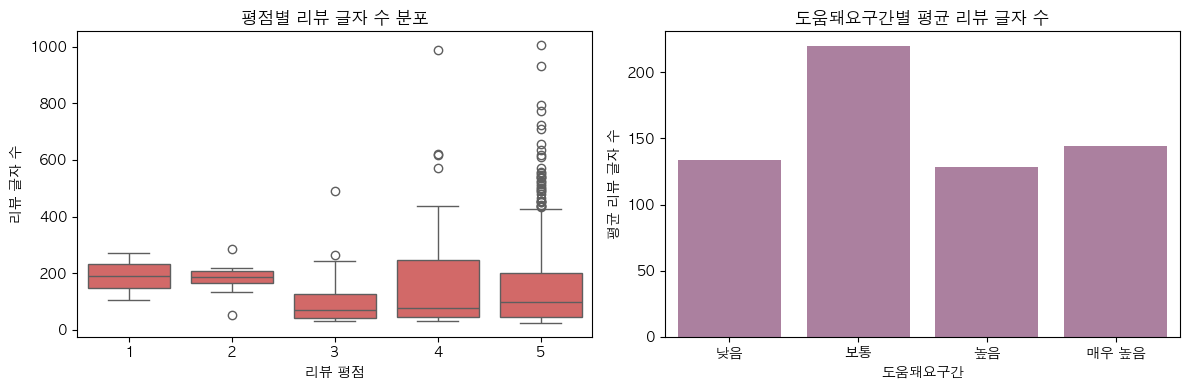

In [46]:
# 리뷰 길이, 평점, 도움돼요구간 관계 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=review_data, x="리뷰평점", y="리뷰글자수", color="#E45756", ax=axes[0])
axes[0].set_title("평점별 리뷰 글자 수 분포")
axes[0].set_xlabel("리뷰 평점")
axes[0].set_ylabel("리뷰 글자 수")

sns.barplot(data=help_length_rating_response, x="도움돼요구간", y="평균리뷰글자수", color="#B279A2", ax=axes[1])
axes[1].set_title("도움돼요구간별 평균 리뷰 글자 수")
axes[1].set_xlabel("도움돼요구간")
axes[1].set_ylabel("평균 리뷰 글자 수")

plt.tight_layout()
plt.show()


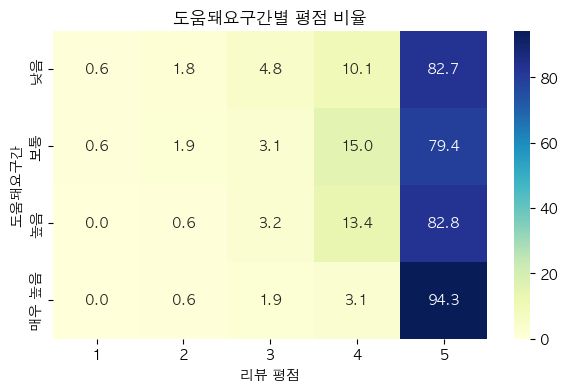

In [47]:
# 도움돼요구간별 평점 비율 시각화
help_rating_ratio = pd.crosstab(
    review_data["도움돼요구간"],
    review_data["리뷰평점"],
    normalize="index",
).mul(100).round(1)

help_rating_ratio = help_rating_ratio.reindex(help_labels)

plt.figure(figsize=(7, 4))
sns.heatmap(help_rating_ratio, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("도움돼요구간별 평점 비율")
plt.xlabel("리뷰 평점")
plt.ylabel("도움돼요구간")
plt.show()


**리뷰 길이, 평점, 도움돼요구간 요약**

- 리뷰 글자 수와 평점의 상관은 거의 크지 않아, 긴 리뷰가 반드시 낮은 평점이나 높은 평점으로 이어지지는 않았습니다.
- <b>1점 리뷰</b>는 표본이 2건으로 적지만 평균 <b>189.0자</b>, <b>2점 리뷰</b>는 평균 <b>180.9자</b>로 작성되어 낮은 평점 리뷰도 비교적 자세한 편이었습니다.
- <b>5점 리뷰</b>는 546건으로 가장 많고 평균 <b>155.5자</b> 수준이었습니다.
- 도움돼요구간 기준으로는 <b>보통</b> 구간의 평균 리뷰 글자 수가 <b>220.0자</b>로 가장 길었고, <b>매우 높음</b> 구간은 평균 평점이 <b>4.91점</b>으로 가장 높았습니다.
- 따라서 도움돼요 반응은 리뷰 길이만으로 설명하기보다, 평점, 사진 여부, 실제 사용 경험의 구체성과 함께 해석하는 것이 좋습니다.


#### 5-2-6. 옵션혜택별 리뷰 반응

`옵션혜택`에서 `일반`은 별도 혜택이 없다는 뜻이므로, 먼저 일반을 기준선으로 두고 혜택 있음/없음을 비교합니다.  
그다음 `일반`을 제외한 혜택 옵션만 따로 비교해, 혜택 자체가 의미가 있는지와 어떤 혜택에 집중하면 좋을지 확인합니다.


In [48]:
# 옵션혜택별 리뷰 반응 집계
# 일반은 혜택 없음 기준선으로 해석합니다.
option_analysis_data = review_data.copy()
option_analysis_data["혜택여부"] = np.where(option_analysis_data["옵션혜택"] == "일반", "혜택 없음(일반)", "혜택 있음")

option_benefit_response = (
    option_analysis_data
    .groupby("옵션혜택")
    .agg(
        리뷰수=("리뷰내용", "count"),
        평균평점=("리뷰평점", "mean"),
        평균리뷰글자수=("리뷰글자수", "mean"),
        사진리뷰비율=("사진여부", lambda x: x.mean() * 100),
        매우높은도움돼요비율=("도움돼요구간", lambda x: (x == "매우 높음").mean() * 100),
        낮은평점비율=("리뷰평점", lambda x: (x <= 3).mean() * 100),
    )
    .reset_index()
)

option_benefit_response["리뷰비율(%)"] = (option_benefit_response["리뷰수"] / len(option_analysis_data) * 100).round(1)
option_benefit_response["평균평점"] = option_benefit_response["평균평점"].round(2)
option_benefit_response["평균리뷰글자수"] = option_benefit_response["평균리뷰글자수"].round(1)
option_benefit_response["사진리뷰비율"] = option_benefit_response["사진리뷰비율"].round(1)
option_benefit_response["매우높은도움돼요비율"] = option_benefit_response["매우높은도움돼요비율"].round(1)
option_benefit_response["낮은평점비율"] = option_benefit_response["낮은평점비율"].round(1)
option_benefit_response = option_benefit_response.sort_values("리뷰수", ascending=False)

option_benefit_response


,옵션혜택,리뷰수,평균평점,평균리뷰글자수,사진리뷰비율,매우높은도움돼요비율,낮은평점비율,리뷰비율(%)
7,일반,474,4.8,168.2,64.8,25.1,4.4,73.6
1,기획,50,4.7,116.7,44.0,36.0,6.0,7.8
5,단품,50,4.8,108.7,34.0,18.0,4.0,7.8
6,올영픽,22,4.7,94.6,68.2,22.7,4.5,3.4
0,"1+1, 기획",19,4.4,215.7,89.5,0.0,15.8,3.0
3,"기획, 증정",15,4.7,147.8,80.0,26.7,6.7,2.3
2,"기획, 신상",7,5.0,126.9,71.4,28.6,0.0,1.1
8,증정,5,4.4,69.0,80.0,20.0,0.0,0.8
4,"기획, 증정, 신상",2,5.0,43.0,50.0,50.0,0.0,0.3


In [49]:
# 혜택 있음/없음 리뷰 반응 비교
benefit_presence_response = (
    option_analysis_data
    .groupby("혜택여부")
    .agg(
        리뷰수=("리뷰내용", "count"),
        평균평점=("리뷰평점", "mean"),
        평균리뷰글자수=("리뷰글자수", "mean"),
        사진리뷰비율=("사진여부", lambda x: x.mean() * 100),
        매우높은도움돼요비율=("도움돼요구간", lambda x: (x == "매우 높음").mean() * 100),
        낮은평점비율=("리뷰평점", lambda x: (x <= 3).mean() * 100),
    )
    .reset_index()
)

benefit_presence_response["리뷰비율(%)"] = (benefit_presence_response["리뷰수"] / len(option_analysis_data) * 100).round(1)
benefit_presence_response["평균평점"] = benefit_presence_response["평균평점"].round(2)
benefit_presence_response["평균리뷰글자수"] = benefit_presence_response["평균리뷰글자수"].round(1)
benefit_presence_response["사진리뷰비율"] = benefit_presence_response["사진리뷰비율"].round(1)
benefit_presence_response["매우높은도움돼요비율"] = benefit_presence_response["매우높은도움돼요비율"].round(1)
benefit_presence_response["낮은평점비율"] = benefit_presence_response["낮은평점비율"].round(1)

benefit_presence_response


,혜택여부,리뷰수,평균평점,평균리뷰글자수,사진리뷰비율,매우높은도움돼요비율,낮은평점비율,리뷰비율(%)
0,혜택 없음(일반),474,4.8,168.2,64.8,25.1,4.4,73.6
1,혜택 있음,170,4.7,123.4,54.7,23.5,5.9,26.4


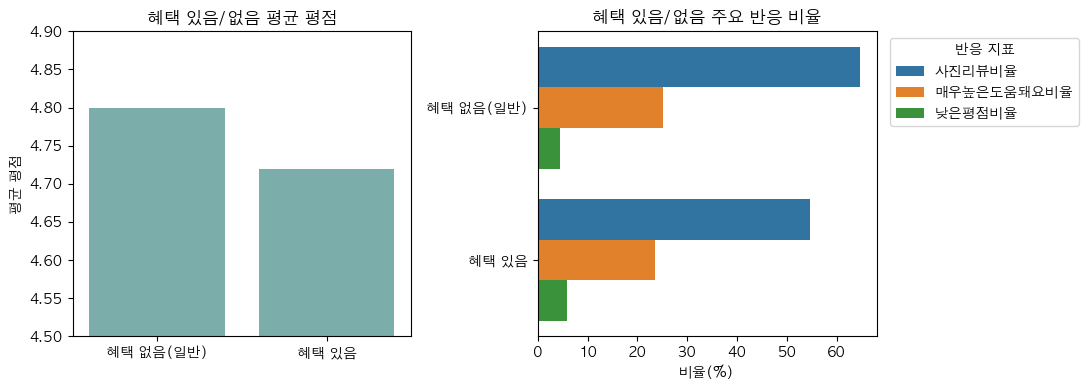

In [50]:
# 혜택 있음/없음 주요 반응 시각화
benefit_presence_rate = benefit_presence_response.melt(
    id_vars="혜택여부",
    value_vars=["사진리뷰비율", "매우높은도움돼요비율", "낮은평점비율"],
    var_name="반응지표",
    value_name="비율(%)",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=benefit_presence_response, x="혜택여부", y="평균평점", color="#72B7B2", ax=axes[0])
axes[0].set_title("혜택 있음/없음 평균 평점")
axes[0].set_xlabel("")
axes[0].set_ylabel("평균 평점")
axes[0].set_ylim(4.5, 4.9)

sns.barplot(data=benefit_presence_rate, x="비율(%)", y="혜택여부", hue="반응지표", ax=axes[1])
axes[1].set_title("혜택 있음/없음 주요 반응 비율")
axes[1].set_xlabel("비율(%)")
axes[1].set_ylabel("")
axes[1].legend(title="반응 지표", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [51]:
# 일반 제외: 혜택 옵션끼리만 비교
option_benefit_only_response = (
    option_benefit_response[option_benefit_response["옵션혜택"] != "일반"]
    .copy()
    .sort_values("리뷰수", ascending=False)
)

option_benefit_only_response


,옵션혜택,리뷰수,평균평점,평균리뷰글자수,사진리뷰비율,매우높은도움돼요비율,낮은평점비율,리뷰비율(%)
1,기획,50,4.7,116.7,44.0,36.0,6.0,7.8
5,단품,50,4.8,108.7,34.0,18.0,4.0,7.8
6,올영픽,22,4.7,94.6,68.2,22.7,4.5,3.4
0,"1+1, 기획",19,4.4,215.7,89.5,0.0,15.8,3.0
3,"기획, 증정",15,4.7,147.8,80.0,26.7,6.7,2.3
2,"기획, 신상",7,5.0,126.9,71.4,28.6,0.0,1.1
8,증정,5,4.4,69.0,80.0,20.0,0.0,0.8
4,"기획, 증정, 신상",2,5.0,43.0,50.0,50.0,0.0,0.3


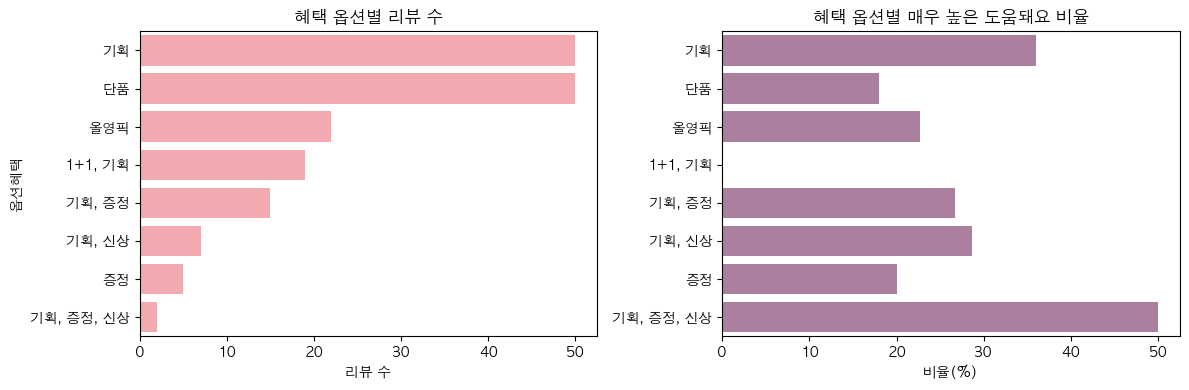

In [52]:
# 일반 제외: 혜택 옵션별 규모와 관심도 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=option_benefit_only_response, x="리뷰수", y="옵션혜택", color="#FF9DA6", ax=axes[0])
axes[0].set_title("혜택 옵션별 리뷰 수")
axes[0].set_xlabel("리뷰 수")
axes[0].set_ylabel("옵션혜택")

sns.barplot(data=option_benefit_only_response, x="매우높은도움돼요비율", y="옵션혜택", color="#B279A2", ax=axes[1])
axes[1].set_title("혜택 옵션별 매우 높은 도움돼요 비율")
axes[1].set_xlabel("비율(%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


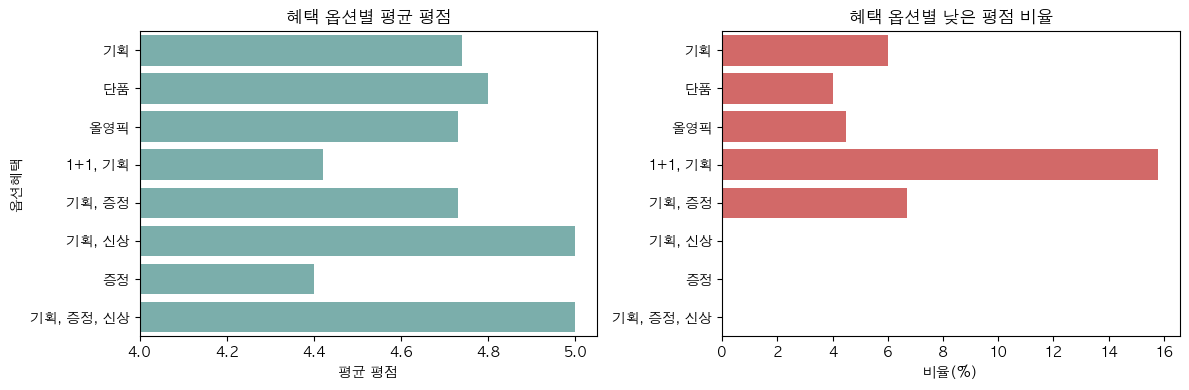

In [53]:
# 일반 제외: 혜택 옵션별 평점 리스크 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=option_benefit_only_response, x="평균평점", y="옵션혜택", color="#72B7B2", ax=axes[0])
axes[0].set_title("혜택 옵션별 평균 평점")
axes[0].set_xlabel("평균 평점")
axes[0].set_ylabel("옵션혜택")
axes[0].set_xlim(4.0, 5.05)

sns.barplot(data=option_benefit_only_response, x="낮은평점비율", y="옵션혜택", color="#E45756", ax=axes[1])
axes[1].set_title("혜택 옵션별 낮은 평점 비율")
axes[1].set_xlabel("비율(%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


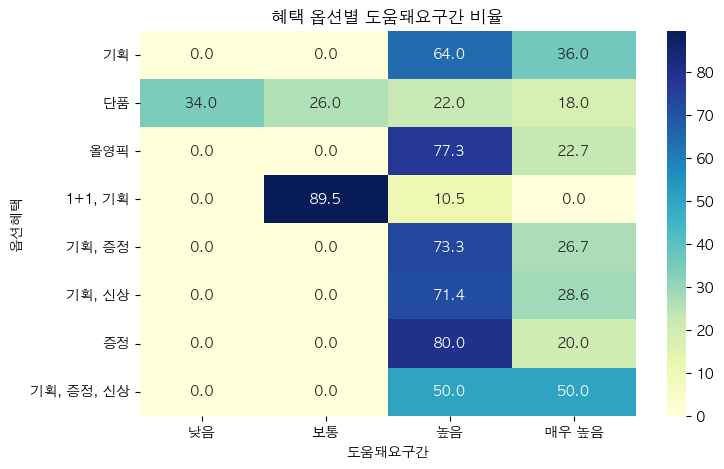

In [54]:
# 일반 제외: 혜택 옵션별 도움돼요구간 비율 확인
option_help_ratio = pd.crosstab(
    option_analysis_data["옵션혜택"],
    option_analysis_data["도움돼요구간"],
    normalize="index",
).mul(100).round(1)

option_help_ratio = option_help_ratio.reindex(option_benefit_only_response["옵션혜택"])

plt.figure(figsize=(8, 5))
sns.heatmap(option_help_ratio, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("혜택 옵션별 도움돼요구간 비율")
plt.xlabel("도움돼요구간")
plt.ylabel("옵션혜택")
plt.show()


In [55]:
# 일반 제외: 혜택 옵션별 가격대 비율 확인
option_price_ratio = pd.crosstab(
    option_analysis_data["옵션혜택"],
    option_analysis_data["가격대"],
    normalize="index",
).mul(100).round(1)

option_price_ratio = option_price_ratio.reindex(option_benefit_only_response["옵션혜택"])
option_price_ratio


가격대,1만원 미만,1만원대,2만원대,3만원 이상
옵션혜택,,,,
기획,0.0,40.0,60.0,0.0
단품,0.0,32.0,68.0,0.0
올영픽,90.9,0.0,9.1,0.0
"1+1, 기획",0.0,100.0,0.0,0.0
"기획, 증정",0.0,80.0,20.0,0.0
"기획, 신상",0.0,100.0,0.0,0.0
증정,0.0,0.0,100.0,0.0
"기획, 증정, 신상",0.0,0.0,100.0,0.0


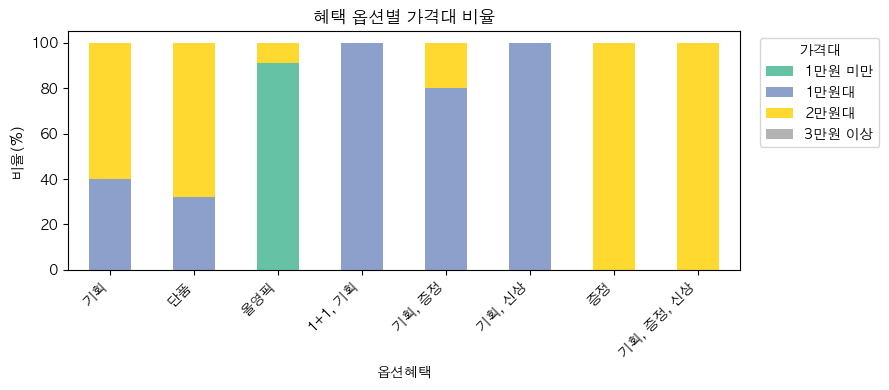

In [56]:
# 일반 제외: 혜택 옵션별 가격대 비율 시각화
option_price_ratio.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="Set2")
plt.title("혜택 옵션별 가격대 비율")
plt.xlabel("옵션혜택")
plt.ylabel("비율(%)")
plt.legend(title="가격대", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [57]:
# 혜택 운영 방향 정리
benefit_focus_summary = pd.DataFrame({
    "혜택 방향": ["기획", "단품", "올영픽", "1+1, 기획", "증정/복합 혜택"],
    "읽을 포인트": [
        "리뷰 수와 매우 높은 도움돼요 비율이 모두 높아 관심도 확보에 유리",
        "평균 평점과 낮은 평점 비율이 안정적이지만 관심도는 상대적으로 낮음",
        "저가 가격대와 연결된 노출형 혜택으로 해석 필요",
        "사진 리뷰와 리뷰 길이는 높지만 낮은 평점 비율이 높아 기대 관리 필요",
        "표본이 작아 방향성만 참고하고 추가 데이터 확인 필요",
    ],
    "활용 제안": [
        "혜택을 준다면 우선 검토할 후보",
        "가격/구성보다 제품 만족 안정성이 중요할 때 활용",
        "저가 상품의 발견성과 노출을 높일 때 활용",
        "무조건 확대보다 구성 조건과 기대 문구 점검",
        "별도 결론보다 텍스트 리뷰에서 불만/만족 표현 확인",
    ],
})

benefit_focus_summary


,혜택 방향,읽을 포인트,활용 제안
0,기획,리뷰 수와 매우 높은 도움돼요 비율이 모두 높아 관심도 확보에 유리,혜택을 준다면 우선 검토할 후보
1,단품,평균 평점과 낮은 평점 비율이 안정적이지만 관심도는 상대적으로 낮음,가격/구성보다 제품 만족 안정성이 중요할 때 활용
2,올영픽,저가 가격대와 연결된 노출형 혜택으로 해석 필요,저가 상품의 발견성과 노출을 높일 때 활용
3,"1+1, 기획",사진 리뷰와 리뷰 길이는 높지만 낮은 평점 비율이 높아 기대 관리 필요,무조건 확대보다 구성 조건과 기대 문구 점검
4,증정/복합 혜택,표본이 작아 방향성만 참고하고 추가 데이터 확인 필요,별도 결론보다 텍스트 리뷰에서 불만/만족 표현 확인


**옵션혜택별 리뷰 반응 요약**

- `일반`은 혜택이 없는 기준선이며, 전체 리뷰의 <b>474건(73.6%)</b>을 차지했습니다. 혜택이 있는 리뷰는 <b>170건(26.4%)</b>입니다.
- 혜택 있음 전체는 평균 평점이 <b>4.72점</b>으로 일반(<b>4.80점</b>)보다 높지 않았고, 매우 높은 도움돼요 비율도 <b>23.5%</b>로 일반(<b>25.1%</b>)보다 크지 않았습니다. 즉 혜택 자체가 자동으로 더 좋은 반응을 만든다고 보기는 어렵습니다.
- 일반을 제외하고 보면 `기획`은 <b>50건</b>으로 표본이 크고 매우 높은 도움돼요 비율이 <b>36.0%</b>로 높아, 혜택을 준다면 가장 먼저 볼 후보입니다.
- `단품`은 평균 평점이 비교적 안정적이고 낮은 평점 비율이 <b>4.0%</b>로 낮지만, 매우 높은 도움돼요 비율은 <b>18.0%</b>로 `기획`보다 낮았습니다.
- `1+1, 기획`은 사진 리뷰 비율과 리뷰 길이는 높지만 평균 평점이 낮고 낮은 평점 비율이 <b>15.8%</b>로 높아, 구성 혜택이 오히려 기대 대비 아쉬움으로 이어졌을 가능성이 있습니다.
- 따라서 혜택 전략은 무조건 혜택을 많이 주기보다, <b>기획 구성 중심으로 관심도를 확보</b>하고 `1+1`형 혜택은 가격/구성 기대를 명확히 관리하는 방향이 좋아 보입니다.


**리뷰 EDA 요약**

- 중복 리뷰 제거 후 분석 대상 리뷰는 <b>644건</b>이며, 평점은 5점에 강하게 몰려 있어 소비자 반응 차이를 평점만으로 설명하기 어렵습니다.
- 리뷰는 <b>달리프</b>, <b>클로란</b>, <b>온더바디</b>에 많이 쌓여 있고, 가격대는 <b>1만원대</b> 중심으로 형성되어 있습니다.
- 도움돼요 반응이 높은 리뷰는 평점뿐 아니라 리뷰 길이, 사진 여부, 구체적인 사용 경험과 함께 봐야 합니다.
- `옵션명`과 `옵션혜택`을 분리해본 결과, 향/쿨링 타입과 기획/증정/단품 같은 구성 소구를 따로 분석할 수 있게 되었습니다.
- 따라서 다음 단계에서는 실제 리뷰 문장 안에서 `쿨링감`, `향`, `두피`, `자극`, `가격/구성` 관련 표현을 확인합니다.


## 6-2. 리뷰 텍스트 분석으로 이어질 질문

다음 리뷰 텍스트 분석에서는 아래 질문을 중심으로 소비자 반응을 확인합니다.

- 소비자는 `쿨링감`을 긍정적으로 받아들이는가, 아니면 자극으로 느끼는가?
- `두피 케어`, `유분 관리`, `탈모 기능성` 같은 상품명 소구가 실제 리뷰에서도 언급되는가?
- 가격대별로 만족/불만 포인트가 다르게 나타나는가?
- 브랜드가 강조한 메시지와 소비자가 실제로 언급한 경험 사이에 차이가 있는가?
